In [1]:
# importing major libraries
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Employee_promotion.csv').iloc[:,[-7,-6,-4,-3,-2,-1]]
df

,YearsExperience,NumCertifications,JobTitle,Education,City,Promotion
0,0,0,Software Engineer,Bachelor's,Atlanta,No Promotion
1,5,1,Full Stack Developer,Master's,Milwaukee,No Promotion
2,1,2,Web Developer,Bachelor's,Las Vegas,No Promotion
3,0,0,BI Developer,Master's,Minneapolis,No Promotion
4,2,1,BI Developer,PhD,Austin,No Promotion
...,...,...,...,...,...,...
1195,9,3,SRE,Bachelor's,Jacksonville,No Promotion
1196,4,2,ML Engineer,Bachelor's,Nashville,Got Promotion
1197,1,1,Data Engineer,Bachelor's,Milwaukee,No Promotion
1198,3,0,BI Developer,Bachelor's,San Antonio,No Promotion


# Selecting Numeric Columns

In this step we remove all categorical (string) columns from the dataset.

Machine learning algorithms work more efficiently when the dataset
contains only numerical values.

Therefore we select the important numeric columns:

Features:
- no_of_years_of_exp
- no_of_trainings (number of certificates / trainings)

Target:
- promotion

Using only numeric columns removes the need for encoding techniques.

In [3]:
# Selecting numeric features

x = df[['YearsExperience','NumCertifications']]

# Target variable
y = df['Promotion']

# Splitting the Dataset

To evaluate the performance of the model we split the dataset into:

**Training Data**
- Used to train the machine learning model.

**Testing Data**
- Used to test how well the model performs on unseen data.

Usually we use:
- 80% data for training
- 20% data for testing

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Column Transformer

Machine learning algorithms cannot work with categorical data directly.

Therefore categorical data must be converted into numerical form.

We use **ColumnTransformer** with **OneHotEncoder** to convert categorical
columns into numerical format.

This process is called **encoding**.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Applying Column Transformer

Here we apply **OneHotEncoder** on categorical columns while leaving
numerical columns unchanged.

This ensures that the dataset becomes suitable for machine learning models.

In [6]:
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), [0])
    ],
    remainder='passthrough'
)

x_train = ct.fit_transform(x_train)
x_test = ct.transform(x_test)

# Decision Tree Algorithm

Decision Tree is a supervised machine learning algorithm used for classification
and regression problems.

It works like a tree structure:

Root Node → Represents the entire dataset  
Decision Nodes → Conditions used to split the data  
Leaf Nodes → Final output or decision  

Decision trees split the dataset using criteria such as:

**Gini Index**  
**Entropy**

In this notebook we use **DecisionTreeClassifier** to predict employee promotion.

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
dtc = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5
)

dtc.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

# Prediction

After training the model we use the testing dataset
to predict whether the employee will get promotion.

In [9]:
y_pred = dtc.predict(x_test)



# Model Accuracy

Accuracy measures how many predictions are correct
compared to the total predictions made by the model.

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


# Decision Tree Visualization

Visualization of the decision tree helps us understand
how the model makes decisions based on the selected features.

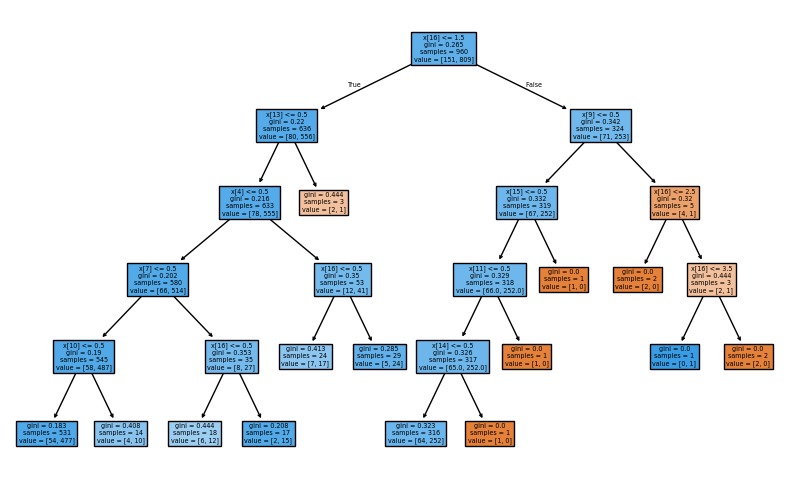

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plot_tree(dtc, filled=True)

plt.show()